In [15]:
## MLCB Assignment 1 - Task 3: Feature Selection

%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import sys
import os
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath('..'))

from src.functions import (load_data, 
                           get_feature_matrix_target_and_features, 
                           split_stratified_data, 
                           build_num_preprocessor,
                           stability_selection, 
                           selection_frequency_distribution,
                           evaluate_model_bootstraping, search_best_K) 

from mrmr import mrmr_regression

from sklearn.pipeline import Pipeline
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import spearmanr

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# load the data, we need the numerical (CpG) features for the stability selection
df_development = load_data('../data/development_data.csv')
target_column = "age" 
first_column_name = df_development.columns[0]
df_development.set_index(first_column_name, inplace=True)

X, y, cpg_features, cat_features = get_feature_matrix_target_and_features(df_development, target_column)
X_train, X_val, y_train, y_val = split_stratified_data(X, y, n_bins=5, test_size=0.2, random_state=42)

# numerical feature matrix for stability selection
X_train_num, X_val_num = X_train[cpg_features], X_val[cpg_features]
X_val_num = X_val_num[cpg_features]

num_preprocessor = build_num_preprocessor()
X_num_preprocessed = num_preprocessor.fit_transform(X_train_num)
X_val_num_preprocessed = num_preprocessor.transform(X_val_num)

# transformed numerical feature matrix as a DataFrame for the names of cpg features to be used 
# in stability selection
X_num_df = pd.DataFrame(X_num_preprocessed, columns=cpg_features, index=X_train_num.index)
X_val_num_df = pd.DataFrame(X_val_num_preprocessed, columns=cpg_features, index=X_val_num.index)

Number of Stable CpG features selected by stability selection: 185
Stable CpG features:

  - cg16867657

  - cg06639320

  - cg24724428

  - cg07553761

  - cg22454769

  - cg06784991

  - cg21572722

  - cg24079702

  - cg03032497

  - cg08234504

  - cg10501210

  - cg04875128

  - cg14692377

  - cg16015712

  - cg19283806

  - cg07547549

  - cg07080372

  - cg23500537

  - cg08160331

  - cg22158769

  - cg01763090

  - cg05991454

  - cg02650266

  - cg09168222

  - cg08097417

  - cg22736354

  - cg01974375

  - cg07955995

  - cg23078123

  - cg07082267

  - cg00292135

  - cg03259243

  - cg11176990

  - cg14361627

  - cg16054275

  - cg03735592

  - cg25994988

  - cg22796704

  - cg23744638

  - cg06240854

  - cg26935102

  - cg16932827

  - cg17471102

  - cg01022345

  - cg10149533

  - cg24466241

  - cg17110586

  - cg08090640

  - cg22285878

  - cg08468401

  - cg16419235

  - cg01528542

  - cg01820374

  - cg15804973

  - cg24711336

  - cg09748749

  - cg04193015


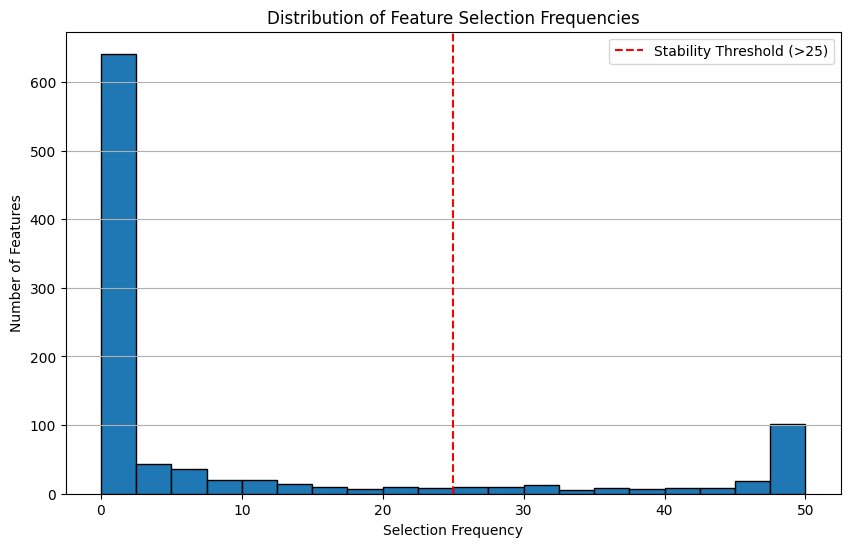

In [3]:
# Stability feature selection
cpg_stable_features, cpg_feature_counts = stability_selection(X_num_df, y_train, n_subsamples=50, subsample_fraction=0.8, random_state=42)
print(f"Number of Stable CpG features selected by stability selection: {len(cpg_stable_features)}")
print(f"Stable CpG features:")
for feature in cpg_stable_features:
    print(f"\n  - {feature}")
print()
selection_frequency_distribution(cpg_feature_counts)

100%|██████████| 10/10 [00:01<00:00,  9.33it/s]


K=  10 → Val RMSE: 7.0349


100%|██████████| 20/20 [00:02<00:00,  8.20it/s]


K=  20 → Val RMSE: 6.4910


100%|██████████| 50/50 [00:05<00:00,  8.38it/s]


...

K= 230 → Val RMSE: 5.8507


100%|██████████| 250/250 [00:29<00:00,  8.62it/s]


K= 250 → Val RMSE: 5.8492


100%|██████████| 300/300 [00:35<00:00,  8.44it/s]


K= 300 → Val RMSE: 5.9037


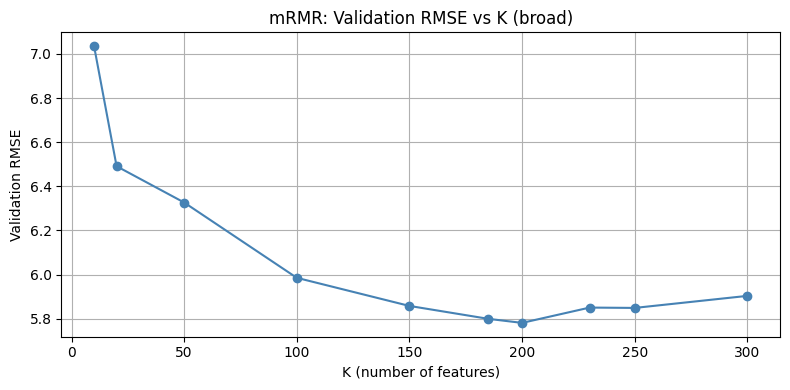


Best K (min RMSE): 200


In [ ]:
# mRMR feature selection using ElsticNet as the proxy model

# Initial broad search of K
# Broad search using ElasticNet as proxy model
_, best_K = search_best_K(
    X_num_df, y_train, X_val_num_df, y_val,
    model=ElasticNet(),
    K_values=[10, 20, 50, 100, 150, 185, 200, 230, 250, 300],
    save_path='../figures/mrmr_K_broad.png',
    title_suffix='(broad)'
)

100%|██████████| 185/185 [00:22<00:00,  8.23it/s]


K= 185 → Val RMSE: 5.7997


100%|██████████| 190/190 [00:21<00:00,  8.92it/s]


K= 190 → Val RMSE: 5.8052


100%|██████████| 195/195 [00:20<00:00,  9.47it/s]


...

K= 215 → Val RMSE: 5.8250


100%|██████████| 220/220 [00:22<00:00,  9.87it/s]


K= 220 → Val RMSE: 5.8300


100%|██████████| 225/225 [00:23<00:00,  9.44it/s]


K= 225 → Val RMSE: 5.8507


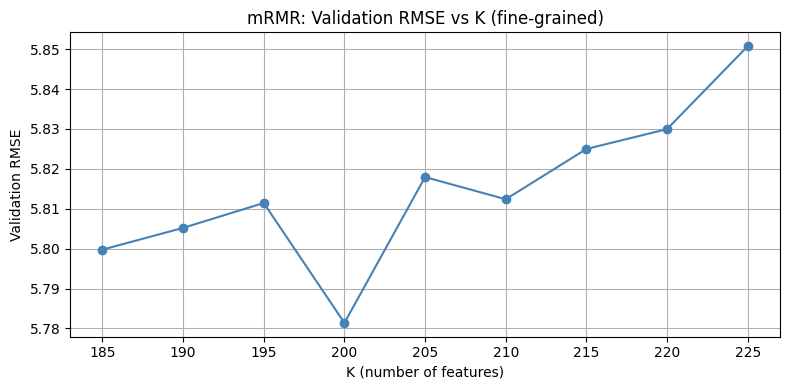


Best K (min RMSE): 200


In [9]:
# Fine-grained search around the minimum
_, best_K = search_best_K(
    X_num_df, y_train, X_val_num_df, y_val,
    model=ElasticNet(),
    K_values=[i for i in range(185, 230, 5)],
    save_path='../figures/mrmr_K_fine.png',
    title_suffix='(fine-grained)'
)

100%|██████████| 190/190 [00:20<00:00,  9.26it/s]


K= 190 → Val RMSE: 5.8052


100%|██████████| 191/191 [00:20<00:00,  9.45it/s]


K= 191 → Val RMSE: 5.8052


100%|██████████| 192/192 [00:20<00:00,  9.51it/s]


...

K= 207 → Val RMSE: 5.8176


100%|██████████| 208/208 [00:20<00:00,  9.93it/s]


K= 208 → Val RMSE: 5.8124


100%|██████████| 209/209 [00:21<00:00,  9.94it/s]


K= 209 → Val RMSE: 5.8124


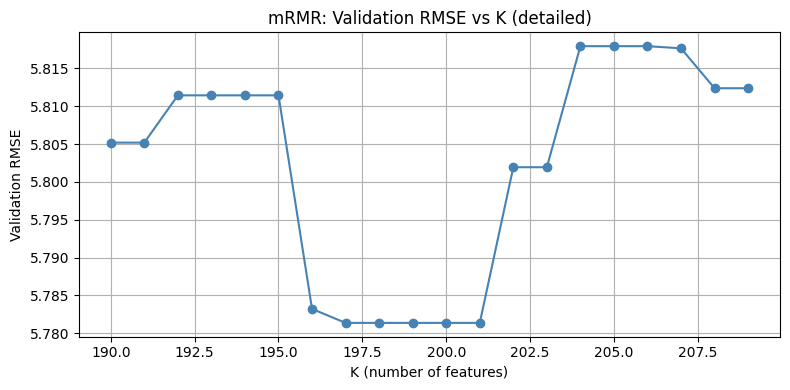


Best K (min RMSE): 197


In [10]:
# even more detailed search around the minimum
_, best_K = search_best_K(
    X_num_df, y_train, X_val_num_df, y_val,
    model=ElasticNet(),
    K_values=[i for i in range(best_K - 10, best_K + 10, 1)],
    save_path='../figures/mrmr_K_detailed.png',
    title_suffix='(detailed)'
)

# K selection for mRMR
The broad search showed a clear minimum around K=200. 
The fine-grained search confirmed that K=197, 199, and 200 all achieve 
the same minimum RMSE=5.7814. By Occam's Razor, K=197 is selected as it achieves 
optimal performance with the fewest features.

100%|██████████| 197/197 [00:20<00:00,  9.39it/s]



Top 10 mRMR Features:
              Feature  |Spearman r|
mRMR Rank                          
1          cg16867657      0.859132
4          cg24724428      0.772669
2          cg06639320      0.749876
7          cg06784991      0.724756
5          cg22454769      0.716579
9          cg07553761      0.713312
11         cg24079702      0.712661
3          cg10501210      0.711637
13         cg14692377      0.696181
6          cg21572722      0.693724


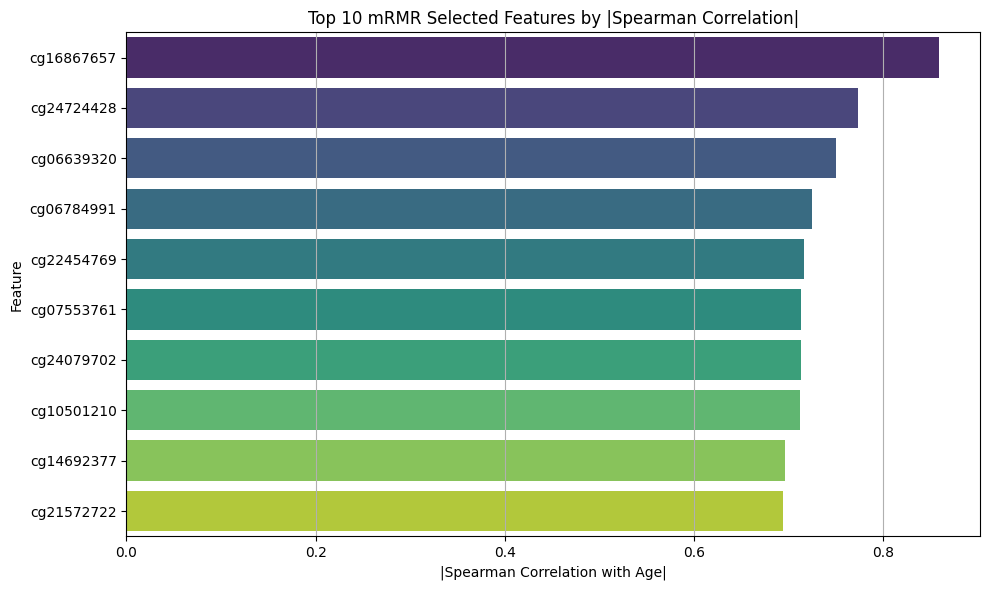

In [16]:
# final mRMR feature selection with the best K=197
cpg_mrmr_features = mrmr_regression(X=X_num_df, y=y_train, K=best_K)

#top 10 importance scores (|Spearman correlation| with the target age)
importance_scores = {}
for feature in cpg_mrmr_features:
    corr, _ = spearmanr(X_num_df[feature], y_train)
    importance_scores[feature] = abs(corr)

all_features_df = pd.DataFrame({
    'Feature': list(importance_scores.keys()),
    '|Spearman r|': list(importance_scores.values()),
    'mRMR Rank': range(1, len(importance_scores) + 1)
}).set_index('mRMR Rank')

top_10_features = all_features_df.sort_values(by='|Spearman r|', ascending=False).head(10)
print("\nTop 10 mRMR Features:")
print(top_10_features)

# bar chart top 10 features
plt.figure(figsize=(10, 6))
sns.barplot(x='|Spearman r|', y='Feature', data=top_10_features.reset_index(), palette='viridis')
plt.xlabel('|Spearman Correlation with Age|')
plt.ylabel('Feature')
plt.title('Top 10 mRMR Selected Features by |Spearman Correlation|')
plt.grid(axis='x')
plt.tight_layout()
plt.savefig('../figures/mrmr_top10_features.png', dpi=150, bbox_inches='tight')
plt.show()

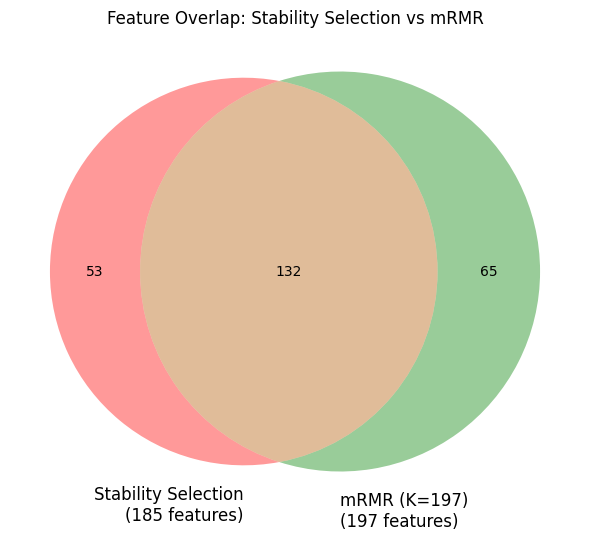

Common features: 132
Only in Stability: 53
Only in mRMR: 65
Percentage of overlap: 52.80%


In [18]:
# examine the intersection of the stability selection and mRMR feature sets
from matplotlib_venn import venn2

stability_set = set(cpg_stable_features)
mrmr_set = set(cpg_mrmr_features)

plt.figure(figsize=(6, 6))
venn2(
    [stability_set, mrmr_set],
    set_labels=(
        f'Stability Selection\n({len(stability_set)} features)',
        f'mRMR (K={best_K})\n({len(mrmr_set)} features)'
    )
)
plt.title('Feature Overlap: Stability Selection vs mRMR')
plt.tight_layout()
plt.savefig('../figures/venn_overlap.png', dpi=150, bbox_inches='tight')
plt.show()

overlap = stability_set & mrmr_set
print(f"Common features: {len(overlap)}")
print(f"Only in Stability: {len(stability_set - mrmr_set)}")
print(f"Only in mRMR: {len(mrmr_set - stability_set)}")

# percentage of overlap
total_unique = len(stability_set | mrmr_set)
overlap_percentage = (len(overlap) / total_unique) * 100 if total_unique > 0 else 0
print(f"Percentage of overlap: {overlap_percentage:.2f}%")

In [ ]:
# Methods comparison using ElasticNet as a proxy model for the selected feature sets of the
# two methods, evaluated on the validation set

X_stable = X_num_df[cpg_stable_features] # Stability selection feature matrix
X_mrmr = X_num_df[cpg_mrmr_features] # mRMR feature matrix

pipe_stable = Pipeline([
    ('model', ElasticNet())
])
pipe_stable.fit(X_stable, y_train)
y_pred_stable = pipe_stable.predict(X_val_num_df[cpg_stable_features])
rmse_stable = np.sqrt(mean_squared_error(y_val, y_pred_stable))
r2_stable = r2_score(y_val, y_pred_stable)

pipe_mrmr = Pipeline([
    ('model', ElasticNet())
])
pipe_mrmr.fit(X_mrmr, y_train)
y_pred_mrmr = pipe_mrmr.predict(X_val_num_df[cpg_mrmr_features])
rmse_mrmr = np.sqrt(mean_squared_error(y_val, y_pred_mrmr))
r2_mrmr = r2_score(y_val, y_pred_mrmr)

print(f"Stability Selection (185 features) → Val RMSE: {rmse_stable:.4f}, R²: {r2_stable:.4f}")
print(f"mRMR (K={best_K}) → Val RMSE: {rmse_mrmr:.4f}, R²: {r2_mrmr:.4f}")

Stability Selection (185 features) → Val RMSE: 6.1579, R²: 0.8218
mRMR (K=197) → Val RMSE: 5.7814, R²: 0.8429


In [ ]:
# Note: X_num_df and X_val_num_df are already imputed and scaled (preprocessed in Cell 2),
# so no preprocessor step is needed in the proxy pipelines here.

# Selected method: mRMR (K=197)

mRMR outperforms Stability Selection on both metrics (RMSE: 5.78 vs 6.16, R²: 0.843 vs 0.822).
This is consistent with the theoretical advantage of mRMR: while Stability Selection identifies 
individually relevant features, it ignores inter-feature redundancy. mRMR explicitly optimizes 
the relevance-redundancy trade-off, selecting a more informative and less correlated feature set.

In [21]:
comparison_table = pd.DataFrame({
    'Method':   ['Stability Selection', f'mRMR (K={best_K})'],
    'Features': [len(cpg_stable_features), best_K],
    'Val RMSE': [round(rmse_stable, 4), round(rmse_mrmr, 4)],
    'Val R²':   [round(r2_stable, 4),   round(r2_mrmr, 4)],
    'Selected': ['', '✓']
}).set_index('Method')

display(comparison_table)

,Features,Val RMSE,Val R²,Selected
Method,,,,
Stability Selection,185,6.1579,0.8218,
mRMR (K=197),197,5.7814,0.8429,✓
